Let's try to recreate Zollman's bandit model

In [1]:
import mesa
from mesa.discrete_space import Network, FixedAgent, CellCollection
import random
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt


Here we define the Agents in our model, both their characteristics and their behavoiour.

In [2]:
class Scientist(FixedAgent):

    def __init__(self, model, cell, a_objective, b_objective, max_priors, stubborness_range):
        super().__init__(model)
        self.cell = cell
        self.a_objective = a_objective
        self.b_objective = b_objective
        self.max_priors = max_priors
        self.stubborness_range = stubborness_range

        #Prior beliefs of each agent
        self.priors = {
        "a_alpha": random.randint(1, self.max_priors),
        "a_beta": random.randint(1, self.max_priors),
        "b_alpha": random.randint(1, self.max_priors),
        "b_beta": random.randint(1, self.max_priors),
        }

        #Define whether the agents prefers to pull the A or B lever as it's state
        if self.a_expectations() > self.b_expectations():
            self.state = "a"
        else:
            self.state = "b"
        
        #Define the level of stubborness of the agent
        self.stubborness = .1 * random.randint(0, self.stubborness_range)
        
        self.experiment_result = (0, 0, 0)
        

    #Funcions for calculating expectations for each hypotheses
    def a_expectations(self):
        a_exp = self.priors["a_alpha"] / (self.priors ["a_alpha"] + self.priors ["a_beta"])
        return a_exp

    def b_expectations(self):
        b_exp = self.priors["b_alpha"] / (self.priors ["b_alpha"] + self.priors ["b_beta"])
        return b_exp
    
    #Research behaviour: performing experiments
    def research(self):


        #Choose action based of belief
        if self.state == "a":
            pull = 1
            current_objective_prob = self.a_objective
        else:
            pull = 2
            current_objective_prob = self.b_objective
        
        #Performing experiment (sampling from a binomial distribution)
        if random.random() < current_objective_prob:
            success = 1
        else: 
            success = 0

        self.experiment_result = (pull, success, 1)
        
        return self.experiment_result

    #Update behaviour: updating expectations based non experimental results
    def update(self):
        # Update beliefs based on OWN results
        pull, success, trial = self.experiment_result

        if pull == 1:
            self.priors["a_alpha"] += success
            self.priors["a_beta"] += trial - success
        else:
            self.priors["b_alpha"] += success
            self.priors["b_beta"] += trial - success

        #Update beliefs based on NEIGHBORS results
        for neighbor in self.cell.neighborhood.agents: 
            
            pull, success, trial = neighbor.experiment_result

            if pull == 1:
                self.priors["a_alpha"] += success
                self.priors["a_beta"] += trial - success
            else:
                self.priors["b_alpha"] += success
                self.priors["b_beta"] += trial - success
            
        #Updating preferences for experimentations (include stubborness)    
        if self.state == "a":
            if (self.a_expectations() + self.stubborness) > self.b_expectations():
                self.state = "a"
            else:
                self.state = "b"
        
        else:
            if (self.b_expectations() + self.stubborness) > self.a_expectations():
                self.state = "b"
            else:
                self.state = "a"

  

    
    

Here we define the structure of the model

In [3]:
      
def Count_Belief_a(model):
    """Funcion for counting the average expectation of a between agents"""
    agents_a_exp = [agent.priors["a_alpha"] / 
            (agent.priors ["a_alpha"] + agent.priors ["a_beta"]) for agent in model.agents]
    ma = np.mean(agents_a_exp)

    return ma

       
def Count_Belief_b(model):
    """Function for counting the average experctation of b between agents"""
    agents_b_exp = [agent.priors["b_alpha"] / 
            (agent.priors ["b_alpha"] + agent.priors ["b_beta"]) for agent in model.agents]
    mb = np.mean(agents_b_exp)

    return mb

def Count_Belief(model):
    """Function for calculating the average distance from objective values of hypotheses between agents"""
    agents_a_dev = Count_Belief_a(model)/model.a_objective
    agents_b_dev = Count_Belief_b(model)/model.b_objective

    return (agents_a_dev + agents_b_dev) / 2



class Bandit(mesa.Model):


    def __init__(
            self, 
            n=10,
            a_objective = .5, 
            b_objective = .4999, 
            max_priors = 4,
            graph = "complete",
            stubborness_range = 0,
                    ):

        super().__init__()
        self.num_agents = n
        self.a_objective = a_objective
        self.b_objective = b_objective
        self.stubborness_range = stubborness_range
        #Defining the graph type
        if graph == "complete":
            self.grid = Network(nx.complete_graph(n))
        elif graph == "wheel":
            self.grid = Network(nx.wheel_graph(n))
        elif graph == "cycle":
            self.grid = Network(nx.cycle_graph(n))
        # Create agents
        Scientist.create_agents(
            model=self, n=n, cell=list(self.grid.all_cells.cells), a_objective = a_objective, b_objective = b_objective, max_priors = max_priors, stubborness_range = stubborness_range)
    
        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={"Avg. deviance from objectve": Count_Belief, "Avg. A expectation": Count_Belief_a, "Avg. B expectation": Count_Belief_b}
        )
        #Create dictionaries for total experiments results
        self.experiments_results_a = {
            "successes": 0,
            "trials": 0
        }
        self.experiments_results_b = {
            "successes": 0,
            "trials": 0
        }

       
    def Count_State_a(self):
        """Function for counting how may agents prefer to pull A"""
        return sum(1 for a in self.agents if a.state == "a")/sum(1 for _ in self.agents)

    def Count_Evidence(self):
        """Function for collecting the experiments results"""

        self.experiments_round_results_a = {
            "successes": 0,
            "trials": 0
        }
        self.experiments_round_results_b = {
            "successes": 0,
            "trials": 0
        }
        for a in self.agents:
            action, success, trial = a.experiment_result
            if action == 1:
                self.experiments_round_results_a["successes"] += success
                self.experiments_round_results_a["trials"] += trial
            else:
                self.experiments_round_results_b["successes"] += success
                self.experiments_round_results_b["trials"] += trial


        return self.experiments_round_results_a, self.experiments_round_results_b
            
    def Update_Evidence(self):
        """Function for updating experiment results data"""
        self.experiments_results_a["successes"] += self.experiments_round_results_a["successes"]
        self.experiments_results_a["trials"] += self.experiments_round_results_a["trials"]
        self.experiments_results_b["successes"] += self.experiments_round_results_b["successes"]
        self.experiments_results_b["trials"] += self.experiments_round_results_b["trials"]          


    def step(self):
        """Advance the model by one step."""
        self.datacollector.collect(self)       
        self.agents.do("research")
        self.Count_Evidence()
        self.Update_Evidence()
        self.agents.do("update")
        


Let's run the model with default parameters for 100 steps

In [4]:
model = Bandit(10)
for _ in range(100):
    model.step()


c:\Users\gugli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\discrete_space\network.py:41: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)


let's try to gather data about converging on the right hypothesis

[Text(0.5, 1.0, 'Convergence over time'), Text(0, 0.5, 'Convergence')]

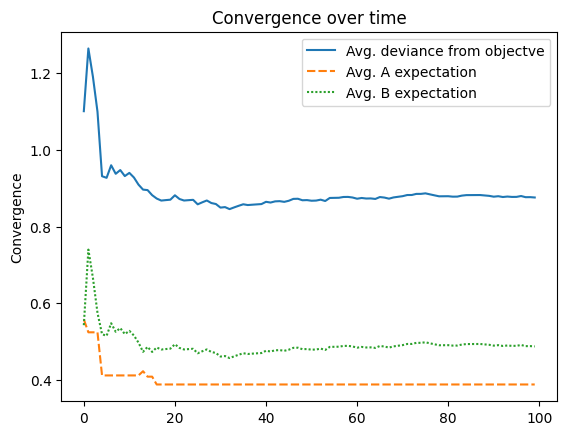

In [5]:
res = model.datacollector.get_model_vars_dataframe()


r = sns.lineplot(data=res)
r.set(title="Convergence over time", ylabel="Convergence")


In [6]:
import math

import solara

from mesa.visualization import (
    Slider,
    SolaraViz,
    SpaceRenderer,
    #make_plot_component,
)
from mesa.visualization.components import AgentPortrayalStyle
from matplotlib.figure import Figure

from mesa.visualization.utils import update_counter

c:\Users\gugli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\solara\validate_hooks.py:122: UserWarning: c:\Users\gugli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\visualization\solara_viz.py:399: ComponentsView: `use_state` found despite early return on line 376
To suppress this check, replace the line with:
    current_tab_index, set_current_tab_index = solara.use_state(0)  # noqa: SH101

Make sure you understand the consequences of this, by reading about the rules of hooks at:
    https://solara.dev/documentation/advanced/understanding/rules-of-hooks

  warnings.warn(str(e))


Here we create an app tu run the model interactively

In [ ]:
def agent_portrayal(agent):
    """Portrays agents as green if they pull A and red if they pull B"""
    return AgentPortrayalStyle(color = "green" if agent.state == "a" else "red", size=90)

model_params = {
    "n": {
        "type": "SliderInt",
        "value": 10,
        "label": "Number of agents:",
        "min": 10,
        "max": 100,
        "step": 1,
    },

    "a_objective": Slider(
        value= .5,
        label="Objective probability of A",
        min=.5,
        max=1,
        step=.01
    ),

    "b_objective": Slider(
        value= .49,
        label="Objective probability of B",
        min=0,
        max=.49,
        step=.01
    ),

    "stubborness_range": Slider(
        value=0,
        label="Max stubborness",
        min=0,
        max=8,
        step=1
    ),

    "max_priors": {
        "type": "SliderInt",
        "value": 4,
        "label": "Max prior belief",
        "min": 2,
        "max": 10,
        "step": 1
    },

    "graph": { 
        "type": "Select",
        "value": "complete",
        "label": "Type of Graph",
        "values": ["complete", "cycle", "wheel"]
    }
}

@solara.component
def deviation_plot(Model):
    """Plot component for avg. A and B expectations and deviance from objective"""
    update_counter.get()
    
    fig = Figure()
    ax = fig.subplots()
    dev = Model.datacollector.get_model_vars_dataframe()
    ax.plot("Avg. deviance from objectve", data=dev, label="Avg. expetation/objectve")
    ax.plot("Avg. A expectation", data=dev, label="Avg. A expectation")
    ax.plot("Avg. B expectation", data=dev, label="Avg. B expectation")
    ax.get_label()
    ax.legend()

    
    solara.FigureMatplotlib(fig)



def get_perc_a_believers(model):
    """Displays the number of agents pulling A"""
    ratio = model.Count_State_a() * 100
    ratio_text = f"{ratio:.2f}"

    return solara.Markdown(
        f"Percentage of agent pursuing theory a: {ratio_text}%"
    )

def get_experiments_round_results(model):
    """Function for displayng step and total experimentals results"""
    res_round_a, res_round_b = model.Count_Evidence()
    res_tot_a = model.experiments_results_a
    res_tot_b = model.experiments_results_b
    eva = res_tot_a["successes"] / res_tot_a["trials"] if res_tot_a["trials"] > 0 else 0
    evb = res_tot_b["successes"] / res_tot_b["trials"] if res_tot_b["trials"] > 0 else 0
    return solara.Markdown(
        f"STEP:<br>Number of experiments for A: {res_round_a["trials"]} with {res_round_a["successes"]} successes <br>Number of experiments for B: {res_round_b["trials"]} with {res_round_b["successes"]} successes<br>TOTAL:<br>Total number of experiments for A: {res_tot_a["trials"]} with {res_tot_a["successes"]} successes<br>Total number of experiments for B: {res_tot_b["trials"]} with {res_tot_b["successes"]} successes<br>Evidence based a = {eva}<br>Evidence based b = {evb}"
    )
    


    

c:\Users\gugli\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\discrete_space\network.py:41: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)


Cannot show ipywidgets in text

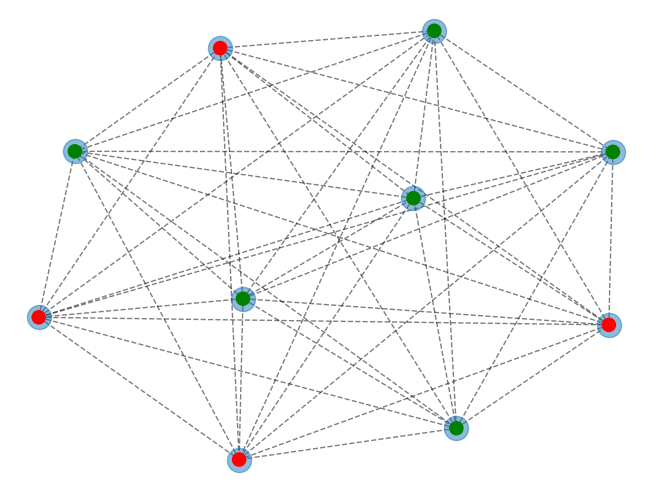

In [8]:
zollman_model = Bandit()

renderer = SpaceRenderer(model=zollman_model, backend="matplotlib").render(agent_portrayal=agent_portrayal)

# This is required to render the visualization in the Jupyter notebook
# To run the visualization on a py file go to run.py 
page = SolaraViz(
    zollman_model,
    renderer,
    model_params=model_params,
    components=[deviation_plot, get_perc_a_believers, get_experiments_round_results],
    name="Zollman Model"
)

page